# SABER Feature EDA — GS & COST

Data source: Financial Modeling Prep (FMP) stable API  
Scope: Balance sheet, income statement, cash flow, daily prices, key metrics, macro indicators

In [157]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

API_KEY = 'AQ7vZFufNFKFggLRz4E8wpBmEETEBcy9'
BASE    = 'https://financialmodelingprep.com/stable'
TICKERS = ['GS', 'COST', 'MSFT', 'AMZN', 'AAPL', 'GOOGL', 'META', 'NVDA', 'TSLA']

In [158]:
# ── helpers ──────────────────────────────────────────────
def fmp_get(endpoint, **params):
    """Fetch JSON from FMP stable API."""
    params['apikey'] = API_KEY
    r = requests.get(f'{BASE}/{endpoint}', params=params)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame([data])

def camel_to_snake(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

def snakeify(df):
    df.columns = [camel_to_snake(c) for c in df.columns]
    return df

## 1. Data Fetching

In [159]:
# ── Company profiles ─────────────────────────────────────
profiles = pd.concat(
    [fmp_get('profile', symbol=t) for t in TICKERS], ignore_index=True
)
profiles = snakeify(profiles)
print(f'Profiles: {profiles.shape}')

# show available columns so we pick the right names
profile_show = [c for c in ['symbol', 'company_name', 'sector', 'industry',
    'country', 'market_cap', 'mkt_cap', 'exchange'] if c in profiles.columns]
profiles[profile_show].head()

Profiles: (9, 36)


,symbol,company_name,sector,industry,country,market_cap,exchange
0,GS,"The Goldman Sachs Group, Inc.",Financial Services,Financial - Capital Markets,US,2.493216e+11,NYSE
1,COST,Costco Wholesale Corporation,Consumer Defensive,Discount Stores,US,4.284490e+11,NASDAQ
2,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,US,2.844016e+12,NASDAQ
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Specialty Retail,US,2.255836e+12,NASDAQ
4,AAPL,Apple Inc.,Technology,Consumer Electronics,US,3.696382e+12,NASDAQ


In [160]:
# ── Quarterly financial statements (full history) ─────────
bs_list, inc_list, cf_list = [], [], []

for t in TICKERS:
    bs_list.append(fmp_get('balance-sheet-statement', symbol=t, period='quarter', limit=200))
    inc_list.append(fmp_get('income-statement', symbol=t, period='quarter', limit=200))
    cf_list.append(fmp_get('cash-flow-statement', symbol=t, period='quarter', limit=200))

bs_raw  = snakeify(pd.concat(bs_list, ignore_index=True))
inc_raw = snakeify(pd.concat(inc_list, ignore_index=True))
cf_raw  = snakeify(pd.concat(cf_list, ignore_index=True))

print(f'Balance sheet:    {bs_raw.shape}')
print(f'Income statement: {inc_raw.shape}')
print(f'Cash flow:        {cf_raw.shape}')

Balance sheet:    (1000, 61)
Income statement: (1051, 39)
Cash flow:        (993, 47)


In [161]:
# ── Key metrics & ratios (quarterly, full history) ────────
km_list, rat_list = [], []
for t in TICKERS:
    km_list.append(fmp_get('key-metrics', symbol=t, period='quarter', limit=200))
    rat_list.append(fmp_get('ratios', symbol=t, period='quarter', limit=200))

km_raw  = snakeify(pd.concat(km_list, ignore_index=True))
rat_raw = snakeify(pd.concat(rat_list, ignore_index=True))

print(f'Key metrics: {km_raw.shape}')
print(f'Ratios:      {rat_raw.shape}')

Key metrics: (1051, 47)
Ratios:      (1051, 64)


In [162]:
# ── Daily prices ──────────────────────────────────────────
px_list = []
for t in TICKERS:
    df = fmp_get('historical-price-eod/full', symbol=t)
    df['ticker'] = t
    px_list.append(df)

prices_raw = snakeify(pd.concat(px_list, ignore_index=True))
prices_raw['date'] = pd.to_datetime(prices_raw['date'])
prices_raw = prices_raw.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f'Daily prices: {prices_raw.shape}')
print(f'Date range: {prices_raw["date"].min().date()} → {prices_raw["date"].max().date()}')
prices_raw.head()

Daily prices: (11286, 11)
Date range: 2021-03-25 → 2026-03-23


,symbol,date,open,high,low,close,volume,change,change_percent,vwap,ticker
0,AAPL,2021-03-25,119.54,121.66,119.00,120.59,98844700,1.05,0.87837,120.1975,AAPL
1,AAPL,2021-03-26,120.35,121.48,118.92,121.21,94071234,0.86,0.71458,120.4900,AAPL
2,AAPL,2021-03-29,121.65,122.58,120.73,121.39,80819203,-0.26,-0.21373,121.5875,AAPL
3,AAPL,2021-03-30,120.11,120.40,118.86,119.90,85671919,-0.21,-0.17484,119.8175,AAPL
4,AAPL,2021-03-31,121.65,123.52,121.15,122.15,118323826,0.50,0.41102,122.1175,AAPL


In [163]:
# ── Macro indicators ──────────────────────────────────────
macro_names = {
    'realGDP':             'real_gdp',
    'realGDPPerCapita':    'real_gdp_per_capita',
    'retailSales':         'retail_sales',
    'durableGoods':        'durables',
    'federalFunds':        'federal_funds_rate',
    'CPI':                 'cpi',
    'inflationRate':       'inflation_expectation',
    'unemploymentRate':    'unemployment',
    'nonFarmPayroll':      'nonfarm_payroll',
}

MACRO_FROM = '2000-01-01'
MACRO_TO   = '2026-12-31'

macro_series = {}
for fmp_name, col_name in macro_names.items():
    try:
        tmp = fmp_get('economic-indicators', name=fmp_name,
                      **{'from': MACRO_FROM, 'to': MACRO_TO})
        tmp['date'] = pd.to_datetime(tmp['date'])
        tmp = tmp.set_index('date')['value'].sort_index().dropna()
        tmp.name = col_name
        macro_series[col_name] = tmp.resample('QE').last()
        print(f'  {col_name:30s} {len(tmp):>5d} raw obs → {len(macro_series[col_name]):>4d} quarters')
    except Exception as e:
        print(f'  {col_name:30s} FAILED: {e}')

# Treasury yield (separate endpoint)
try:
    tsy = fmp_get('treasury-rates', **{'from': MACRO_FROM, 'to': MACRO_TO})
    tsy = snakeify(tsy)
    tsy['date'] = pd.to_datetime(tsy['date'])
    tsy = tsy.set_index('date').sort_index()
    ycol = 'year10' if 'year10' in tsy.columns else tsy.columns[1]
    tsy_q = tsy[ycol].dropna().resample('QE').last()
    tsy_q.name = 'treasury_yield'
    macro_series['treasury_yield'] = tsy_q
    print(f'  {"treasury_yield":30s} {len(tsy):>5d} raw obs → {len(tsy_q):>4d} quarters')
except Exception as e:
    print(f'  treasury_yield FAILED: {e}')

# Combine — all already aligned to quarter-end dates
macro_df = pd.DataFrame(macro_series)
macro_df.index.name = 'date'
macro_df = macro_df.reset_index().sort_values('date').reset_index(drop=True)

print(f'\nMacro combined: {macro_df.shape}')
print(f'NA%: {100*macro_df.isna().mean().mean():.1f}%')
macro_df.tail()

  real_gdp                         104 raw obs →  104 quarters
  real_gdp_per_capita              104 raw obs →  104 quarters
  retail_sales                     313 raw obs →  105 quarters
  durables                         313 raw obs →  105 quarters
  federal_funds_rate               314 raw obs →  105 quarters
  cpi                              313 raw obs →  105 quarters
  inflation_expectation           5808 raw obs →   93 quarters
  unemployment                     313 raw obs →  105 quarters
  nonfarm_payroll                FAILED: Expecting value: line 1 column 1 (char 0)
  treasury_yield                  6559 raw obs →  105 quarters

Macro combined: (105, 10)
NA%: 1.3%


,date,real_gdp,real_gdp_per_capita,retail_sales,durables,federal_funds_rate,cpi,inflation_expectation,unemployment,treasury_yield
100,2025-03-31,23548.210,68979.0,625121,316215,4.33,319.785,2.38,4.2,4.23
101,2025-06-30,23770.976,69549.0,624146,311761,4.33,321.435,2.29,4.1,4.24
102,2025-09-30,24026.834,70218.0,632395,314147,4.22,324.245,2.36,4.4,4.16
103,2025-12-31,24065.956,70279.0,634673,321342,3.72,326.031,2.25,4.4,4.18
104,2026-03-31,NaN,NaN,633709,321314,3.64,327.460,2.33,4.4,4.34


## 2. Tidy Tables — Quick Look

In [164]:
# ── Balance sheet snapshot ────────────────────────────────
bs_key_cols = ['symbol', 'date', 'period', 'total_assets', 'total_liabilities',
               'total_stockholders_equity', 'total_current_assets',
               'total_current_liabilities', 'cash_and_cash_equivalents',
               'net_debt', 'long_term_debt', 'goodwill', 'inventory',
               'net_receivables', 'retained_earnings']
bs_show = [c for c in bs_key_cols if c in bs_raw.columns]
bs_raw[bs_show].head(10)

,symbol,date,period,total_assets,total_liabilities,total_stockholders_equity,total_current_assets,total_current_liabilities,cash_and_cash_equivalents,net_debt,long_term_debt,goodwill,inventory,net_receivables,retained_earnings
0,GS,2025-12-31,Q4,1809320000000,1684348000000,124972000000,1018577000000,1226809000000,164259000000,445275000000,296212000000,5949000000,0,394050000000,165288000000
1,GS,2025-09-30,Q3,1808000000000,1675611000000,124000000000,693000000000,1382000000000,169000000000,496000000000,277000000000,18000000000,0,177000000000,159535000000
2,GS,2025-06-30,Q2,1785009000000,1660913000000,124096000000,367247000000,1232728000000,152967000000,450227000000,286541000000,5952000000,0,200527000000,159535000000
3,GS,2025-03-31,Q1,1766181000000,1641881000000,124300000000,1107249000000,1232087000000,167408000000,442329000000,269653000000,5886000000,0,182365000000,157019000000
4,GS,2024-12-31,Q4,1675972000000,1553976000000,121996000000,1073043000000,1158274000000,182092000000,434843000000,249869000000,5853000000,0,151213000000,153412000000
5,GS,2024-09-30,Q3,1728080000000,1606880000000,121200000000,1105119000000,1206007000000,154689000000,458232000000,258324000000,5909000000,0,162368000000,150454000000
6,GS,2024-06-30,Q2,1653313000000,1533850000000,119463000000,1064333000000,1152360000000,206326000000,368459000000,243255000000,5893000000,0,158063000000,148652000000
7,GS,2024-03-31,Q1,1698440000000,1579894000000,118546000000,1102678000000,1203496000000,209385000000,387828000000,240945000000,5897000000,0,176159000000,146690000000
8,GS,2023-12-31,Q4,1641594000000,1524689000000,116905000000,1073522000000,1146220000000,241577000000,341558000000,247867000000,5916000000,0,148577000000,143688000000
9,GS,2023-09-30,Q3,1577153000000,1459876000000,117277000000,1025243000000,1107835000000,239879000000,296783000000,230070000000,5913000000,0,155250000000,142743000000


In [165]:
# ── Income statement snapshot ─────────────────────────────
inc_key_cols = ['symbol', 'date', 'period', 'revenue', 'cost_of_revenue',
                'gross_profit', 'operating_income', 'net_income',
                'ebitda', 'eps', 'eps_diluted', 'interest_expense',
                'income_tax_expense', 'research_and_development_expenses']
inc_show = [c for c in inc_key_cols if c in inc_raw.columns]
inc_raw[inc_show].head(10)

,symbol,date,period,revenue,cost_of_revenue,gross_profit,operating_income,net_income,ebitda,eps,eps_diluted,interest_expense,income_tax_expense,research_and_development_expenses
0,GS,2025-12-31,Q4,30125000000,14548000000,15577000000,5855000000,4617000000,6382000000,14.21,14.00,16671000000,1238000000,0
1,GS,2025-09-30,Q3,32154000000,17309000000,14845000000,5392000000,4098000000,5923000000,12.42,12.25,16970000000,1294000000,0
2,GS,2025-06-30,Q2,31268000000,17069000000,14199000000,4958000000,3723000000,5576000000,11.07,10.95,16685000000,1235000000,0
3,GS,2025-03-31,Q1,31550000000,16775000000,14775000000,5647000000,4738000000,6153000000,14.25,14.12,16488000000,909000000,0
4,GS,2024-12-31,Q4,32240000000,18722000000,13518000000,5257000000,4111000000,5755000000,12.17,11.95,18371000000,1146000000,0
5,GS,2024-09-30,Q3,31524000000,19222000000,12302000000,3987000000,2990000000,4608000000,8.52,8.40,18825000000,997000000,0
6,GS,2024-06-30,Q2,31181000000,18732000000,12449000000,3916000000,3043000000,4562000000,8.73,8.62,18450000000,873000000,0
7,GS,2024-03-31,Q1,32394000000,18499000000,13895000000,5237000000,4132000000,5864000000,11.67,11.58,18181000000,1105000000,0
8,GS,2023-12-31,Q4,28463000000,17722000000,10741000000,2254000000,2008000000,3034000000,5.49,5.53,17145000000,246000000,0
9,GS,2023-09-30,Q3,28527000000,16717000000,11810000000,2756000000,2058000000,4268000000,5.52,5.47,16710000000,698000000,0


In [166]:
# ── Cash flow snapshot ────────────────────────────────────
cf_key_cols = ['symbol', 'date', 'period', 'net_income', 'operating_cash_flow',
               'capital_expenditure', 'free_cash_flow',
               'dividends_paid', 'stock_based_compensation',
               'depreciation_and_amortization', 'change_in_working_capital']
cf_show = [c for c in cf_key_cols if c in cf_raw.columns]
cf_raw[cf_show].head(10)

,symbol,date,period,net_income,operating_cash_flow,capital_expenditure,free_cash_flow,stock_based_compensation,depreciation_and_amortization,change_in_working_capital
0,GS,2025-12-31,Q4,4617000000,-16276000000,-531000000,-16807000000,258000000,527000000,47136000000
1,GS,2025-09-30,Q3,4098000000,2680000000,-558000000,2122000000,237000000,531000000,-2574000000
2,GS,2025-06-30,Q2,3723000000,5672000000,-476000000,5196000000,533000000,618000000,770000000
3,GS,2025-03-31,Q1,4738000000,-37230000000,-499000000,-37729000000,2417000000,506000000,-45332000000
4,GS,2024-12-31,Q4,4111000000,46766000000,-586000000,46180000000,104000000,498000000,41849000000
5,GS,2024-09-30,Q3,2990000000,-38060000000,-466000000,-38526000000,120000000,621000000,-41986000000
6,GS,2024-06-30,Q2,3043000000,6120000000,-542000000,5578000000,595000000,646000000,2065000000
7,GS,2024-03-31,Q1,4132000000,-28038000000,-497000000,-28535000000,1844000000,627000000,-35019000000
8,GS,2023-12-31,Q4,2008000000,-28358000000,-546000000,-28904000000,77000000,780000000,-14892000000
9,GS,2023-09-30,Q3,2058000000,-25534000000,-507000000,-26041000000,228000000,1512000000,23120000000


In [167]:
# ── All available columns per statement ───────────────────
for name, df in [('Balance Sheet', bs_raw), ('Income Statement', inc_raw),
                 ('Cash Flow', cf_raw), ('Key Metrics', km_raw), ('Ratios', rat_raw)]:
    print(f'\n{name} ({df.shape[1]} columns):')
    print(', '.join(sorted(df.columns)))


Balance Sheet (61 columns):
accepted_date, account_payables, accounts_receivables, accrued_expenses, accumulated_other_comprehensive_income_loss, additional_paid_in_capital, capital_lease_obligations, capital_lease_obligations_current, capital_lease_obligations_non_current, cash_and_cash_equivalents, cash_and_short_term_investments, cik, common_stock, date, deferred_revenue, deferred_revenue_non_current, deferred_tax_liabilities_non_current, filing_date, fiscal_year, goodwill, goodwill_and_intangible_assets, intangible_assets, inventory, long_term_debt, long_term_investments, minority_interest, net_debt, net_receivables, other_assets, other_current_assets, other_current_liabilities, other_liabilities, other_non_current_assets, other_non_current_liabilities, other_payables, other_receivables, other_total_stockholders_equity, period, preferred_stock, prepaids, property_plant_equipment_net, reported_currency, retained_earnings, short_term_debt, short_term_investments, symbol, tax_assets,

## 3. Missing Values & Duplicates

In [168]:
def na_report(df, name):
    """Print NA summary: total, % by column, worst offenders."""
    total_cells = df.shape[0] * df.shape[1]
    total_na = df.isna().sum().sum()
    # also count zeros in numeric columns as potential "soft NAs"
    num_cols = df.select_dtypes(include='number').columns
    total_zeros = (df[num_cols] == 0).sum().sum() if len(num_cols) else 0
    
    print(f'\n{"=" * 60}')
    print(f'{name}: {df.shape[0]} rows × {df.shape[1]} cols')
    print(f'  Total NAs:   {total_na:,} / {total_cells:,}  ({100*total_na/total_cells:.1f}%)')
    print(f'  Total zeros: {total_zeros:,} (in numeric cols only)')
    
    na_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    bad = na_pct[na_pct > 0]
    if len(bad):
        print(f'  Columns with NAs ({len(bad)}):')
        for col, pct in bad.head(15).items():
            print(f'    {col:45s} {pct:5.1f}%')
        if len(bad) > 15:
            print(f'    ... and {len(bad)-15} more')
    else:
        print('  No NAs found!')
    return na_pct

na_bs  = na_report(bs_raw, 'Balance Sheet')
na_inc = na_report(inc_raw, 'Income Statement')
na_cf  = na_report(cf_raw, 'Cash Flow')
na_km  = na_report(km_raw, 'Key Metrics')
na_rat = na_report(rat_raw, 'Ratios')
na_px  = na_report(prices_raw, 'Daily Prices')
na_mac = na_report(macro_df, 'Macro')


Balance Sheet: 1000 rows × 61 cols
  Total NAs:   0 / 61,000  (0.0%)
  Total zeros: 17,183 (in numeric cols only)
  No NAs found!

Income Statement: 1051 rows × 39 cols
  Total NAs:   0 / 40,989  (0.0%)
  Total zeros: 7,125 (in numeric cols only)
  No NAs found!

Cash Flow: 993 rows × 47 cols
  Total NAs:   0 / 46,671  (0.0%)
  Total zeros: 9,998 (in numeric cols only)
  No NAs found!

Key Metrics: 1051 rows × 47 cols
  Total NAs:   119 / 49,397  (0.2%)
  Total zeros: 4,148 (in numeric cols only)
  Columns with NAs (1):
    graham_number                                  11.3%

Ratios: 1051 rows × 64 cols
  Total NAs:   0 / 67,264  (0.0%)
  Total zeros: 7,257 (in numeric cols only)
  No NAs found!

Daily Prices: 11286 rows × 11 cols
  Total NAs:   0 / 124,146  (0.0%)
  Total zeros: 33 (in numeric cols only)
  No NAs found!

Macro: 105 rows × 10 cols
  Total NAs:   14 / 1,050  (1.3%)
  Total zeros: 0 (in numeric cols only)
  Columns with NAs (3):
    inflation_expectation               

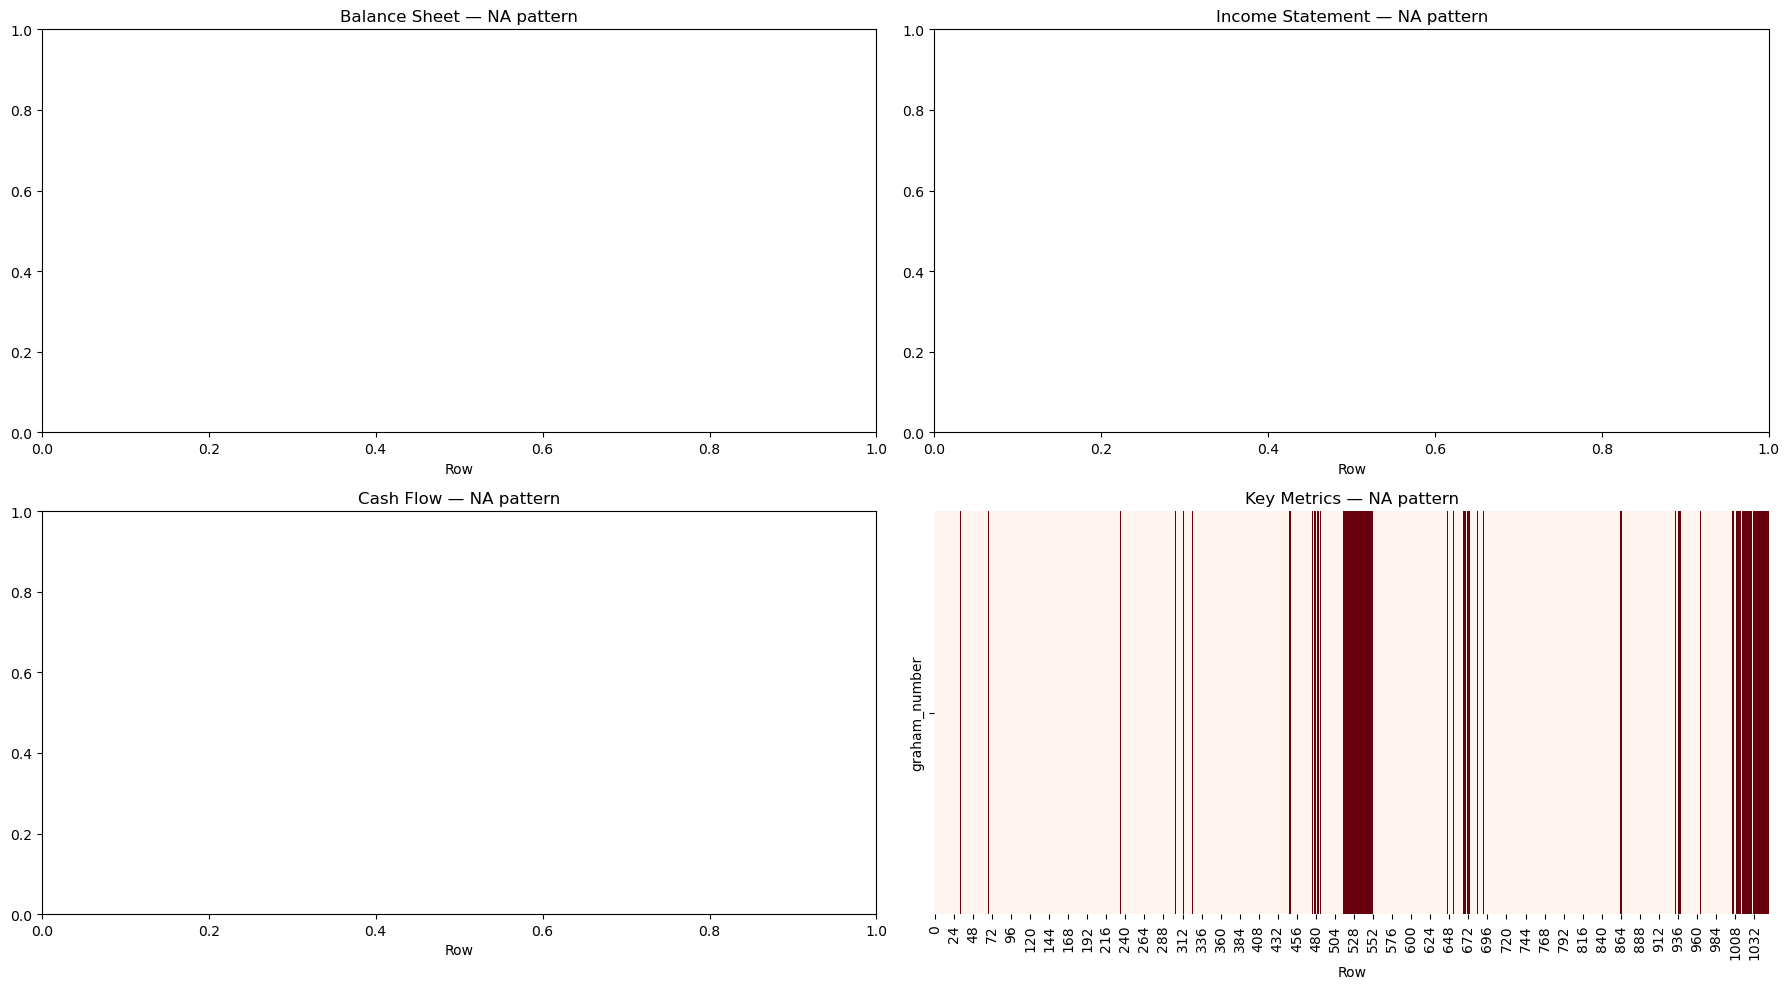

In [169]:
# ── NA heatmap per statement ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, (name, df) in zip(axes.flat,
    [('Balance Sheet', bs_raw), ('Income Statement', inc_raw),
     ('Cash Flow', cf_raw), ('Key Metrics', km_raw)]):
    # show only numeric columns with any NAs
    num = df.select_dtypes(include='number')
    has_na = num.columns[num.isna().any()]
    if len(has_na) > 30:
        has_na = has_na[:30]  # cap for readability
    if len(has_na):
        sns.heatmap(num[has_na].isna().T, cbar=False, ax=ax, cmap='Reds')
    ax.set_title(f'{name} — NA pattern')
    ax.set_xlabel('Row')

plt.tight_layout()
plt.show()

In [170]:
# ── Duplicate check ───────────────────────────────────────
def dup_check(df, name, subset=None):
    n_dup = df.duplicated(subset=subset).sum()
    label = f'(on {subset})' if subset else '(all cols)'
    print(f'{name:25s} {label:30s}: {n_dup} duplicates')
    return n_dup

for name, df, keys in [
    ('Balance Sheet', bs_raw, ['symbol', 'date']),
    ('Income Statement', inc_raw, ['symbol', 'date']),
    ('Cash Flow', cf_raw, ['symbol', 'date']),
    ('Key Metrics', km_raw, ['symbol', 'date']),
    ('Ratios', rat_raw, ['symbol', 'date']),
    ('Daily Prices', prices_raw, ['ticker', 'date']),
]:
    dup_check(df, name, subset=keys)

Balance Sheet             (on ['symbol', 'date'])       : 0 duplicates
Income Statement          (on ['symbol', 'date'])       : 0 duplicates
Cash Flow                 (on ['symbol', 'date'])       : 0 duplicates
Key Metrics               (on ['symbol', 'date'])       : 0 duplicates
Ratios                    (on ['symbol', 'date'])       : 0 duplicates
Daily Prices              (on ['ticker', 'date'])       : 0 duplicates


## 4. Descriptive Statistics

In [171]:
# ── Balance sheet summary per ticker ──────────────────────
bs_num = bs_raw.select_dtypes(include='number')
key_bs_cols = [c for c in ['total_assets', 'total_liabilities',
    'total_stockholders_equity', 'cash_and_cash_equivalents',
    'net_debt', 'long_term_debt', 'total_current_assets',
    'total_current_liabilities', 'retained_earnings'] if c in bs_num.columns]

for t in TICKERS:
    mask = bs_raw['symbol'] == t
    print(f'\n── {t} Balance Sheet ──')
    display(bs_raw.loc[mask, key_bs_cols].describe().round(0))


── GS Balance Sheet ──


,total_assets,total_liabilities,total_stockholders_equity,cash_and_cash_equivalents,net_debt,long_term_debt,total_current_assets,total_current_liabilities,retained_earnings
count,1.070000e+02,1.070000e+02,1.070000e+02,1.070000e+02,1.070000e+02,1.070000e+02,1.070000e+02,1.070000e+02,1.070000e+02
mean,9.229217e+11,8.548367e+11,6.749513e+10,8.189577e+10,3.113034e+11,1.692097e+11,4.054538e+11,5.418030e+11,6.747972e+10
std,4.151720e+11,3.829181e+11,3.582860e+10,8.008627e+10,1.331729e+11,7.849958e+10,3.287560e+11,3.226043e+11,4.892728e+10
min,2.362730e+11,2.276760e+11,7.856000e+09,1.900000e+09,1.035700e+11,2.034000e+10,3.328600e+10,8.463300e+10,-9.170000e+08
25%,7.328125e+11,7.043540e+11,2.845850e+10,7.736000e+09,2.326030e+11,1.081280e+11,1.210380e+11,3.662525e+11,2.025050e+10
50%,9.124950e+11,8.345330e+11,7.571600e+10,6.312900e+10,2.710360e+11,1.885340e+11,3.162690e+11,4.739650e+11,6.263800e+10
75%,1.084959e+12,1.006502e+12,9.022500e+10,1.223730e+11,3.771160e+11,2.316105e+11,6.446290e+11,6.280400e+11,1.029275e+11
max,1.809320e+12,1.684348e+12,1.249720e+11,2.886060e+11,7.273640e+11,2.962120e+11,1.107249e+12,1.382000e+12,1.652880e+11



── COST Balance Sheet ──


,total_assets,total_liabilities,total_stockholders_equity,cash_and_cash_equivalents,net_debt,long_term_debt,total_current_assets,total_current_liabilities,retained_earnings
count,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02,1.510000e+02
mean,2.503151e+10,1.568825e+10,9.198886e+09,3.855713e+09,-5.289658e+08,2.631661e+09,1.244119e+10,1.188461e+10,6.257210e+09
std,2.225426e+10,1.514573e+10,7.285669e+09,4.309991e+09,1.812102e+09,2.351152e+09,1.156503e+10,1.137700e+10,5.421946e+09
min,3.806000e+08,1.912000e+08,1.613000e+08,-3.130000e+07,-9.146000e+09,2.700000e+06,2.338000e+08,1.387000e+08,-2.062000e+09
25%,5.963100e+09,3.242950e+09,2.634550e+09,3.073500e+08,-1.241120e+09,8.137500e+08,2.433200e+09,2.185400e+09,1.779750e+09
50%,1.953848e+10,1.091393e+10,8.971986e+09,2.725116e+09,1.870500e+08,1.303207e+09,9.324153e+09,8.664500e+09,5.736698e+09
75%,3.554050e+10,2.373800e+10,1.218750e+10,5.289000e+09,5.260500e+08,4.985000e+09,1.784600e+10,1.827100e+10,7.534500e+09
max,8.363900e+10,5.248700e+10,3.208700e+10,1.738300e+10,2.113000e+09,7.598000e+09,4.341100e+10,4.180500e+10,2.512100e+10



── MSFT Balance Sheet ──


...

,total_assets,total_liabilities,total_stockholders_equity,cash_and_cash_equivalents,net_debt,long_term_debt,total_current_assets,total_current_liabilities,retained_earnings
count,5.700000e+01,5.700000e+01,5.700000e+01,5.700000e+01,5.700000e+01,5.700000e+01,5.700000e+01,5.700000e+01,5.700000e+01
mean,1.196647e+11,3.151147e+10,8.815321e+10,1.357196e+10,-9.107018e+07,5.773404e+09,4.798402e+10,1.264130e+10,4.410191e+10
std,9.059254e+10,3.482751e+10,5.759441e+10,1.141265e+10,1.210686e+10,1.172502e+10,2.817310e+10,1.249719e+10,3.498688e+10
min,6.331000e+09,1.432000e+09,4.899000e+09,1.282000e+09,-1.327400e+10,0.000000e+00,4.604000e+09,8.990000e+08,1.171000e+09
25%,4.413000e+10,4.678000e+09,3.945200e+10,4.907000e+09,-6.847000e+09,0.000000e+00,1.695100e+10,1.792000e+09,7.330000e+09
50%,9.733400e+10,1.320700e+10,8.412700e+10,1.107600e+10,-3.233000e+09,0.000000e+00,5.048000e+10,7.017000e+09,4.198100e+10
75%,1.706090e+11,4.401200e+10,1.282900e+11,1.660100e+10,-6.700000e+07,1.500000e+09,6.956000e+10,2.221700e+10,6.976100e+10
max,3.660210e+11,1.487780e+11,2.172430e+11,4.388900e+10,4.802400e+10,5.874400e+10,1.087220e+11,4.183600e+10,1.211790e+11



── NVDA Balance Sheet ──


,total_assets,total_liabilities,total_stockholders_equity,cash_and_cash_equivalents,net_debt,long_term_debt,total_current_assets,total_current_liabilities,retained_earnings
count,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02
mean,1.908243e+10,6.450911e+09,1.263152e+10,2.149887e+09,6.680537e+08,2.296077e+09,1.312121e+10,3.090326e+09,1.076695e+10
std,3.497892e+10,1.049738e+10,2.487030e+10,3.367432e+09,3.131191e+09,3.508725e+09,2.360443e+10,5.895456e+09,2.205811e+10
min,1.267000e+08,5.000000e+07,7.670000e+07,4.680000e+07,-8.253000e+09,0.000000e+00,1.034000e+08,3.870000e+07,-3.200000e+06
25%,1.917392e+09,7.212708e+08,1.459354e+09,4.128888e+08,-5.183632e+08,0.000000e+00,1.525218e+09,4.681985e+08,7.697188e+08
50%,5.709770e+09,1.402312e+09,4.178586e+09,6.208955e+08,-2.004715e+08,3.000000e+08,4.040978e+09,9.358955e+08,3.014441e+09
75%,1.420950e+10,4.347500e+09,9.862000e+09,1.989250e+09,9.813882e+08,1.988250e+09,1.138725e+10,1.948750e+09,1.210075e+10
max,2.068030e+11,4.951000e+10,1.572930e+11,1.549400e+10,1.053900e+10,1.094700e+10,1.256050e+11,3.216300e+10,1.469730e+11



── TSLA Balance Sheet ──


,total_assets,total_liabilities,total_stockholders_equity,cash_and_cash_equivalents,net_debt,long_term_debt,total_current_assets,total_current_liabilities,retained_earnings
count,7.100000e+01,7.100000e+01,7.100000e+01,7.100000e+01,7.100000e+01,7.100000e+01,7.100000e+01,7.100000e+01,7.100000e+01
mean,3.563510e+10,1.808126e+10,1.692131e+10,6.418535e+09,-2.376867e+07,3.699221e+09,1.578291e+10,9.979564e+09,3.624863e+09
std,4.180777e+10,1.713550e+10,2.534912e+10,7.126376e+09,5.734465e+09,3.671345e+09,2.024950e+10,1.090914e+10,1.273764e+10
min,8.709250e+06,3.817075e+07,-3.097750e+08,2.319250e+06,-1.365800e+10,0.000000e+00,5.577000e+06,1.282400e+07,-6.331639e+09
25%,9.616835e+08,9.061235e+08,2.590815e+08,2.369180e+08,-2.286500e+09,3.924700e+08,4.712630e+08,4.361755e+08,-3.170212e+09
50%,2.505373e+10,1.889264e+10,4.237242e+09,2.967504e+09,-9.500000e+05,2.095000e+09,6.359444e+09,6.245439e+09,-1.054357e+09
75%,5.649000e+10,2.911800e+10,2.592850e+10,1.544150e+10,1.395283e+09,7.002547e+09,2.585950e+10,1.721100e+10,-4.088075e+07
max,1.378060e+11,5.494100e+10,8.213700e+10,1.953200e+10,1.108452e+10,1.077400e+10,6.864200e+10,3.171400e+10,3.900300e+10


In [172]:
# ── Income statement summary per ticker ───────────────────
key_inc_cols = [c for c in ['revenue', 'gross_profit', 'operating_income',
    'net_income', 'ebitda', 'eps_diluted', 'interest_expense'] if c in inc_raw.columns]

for t in TICKERS:
    mask = inc_raw['symbol'] == t
    print(f'\n── {t} Income Statement ──')
    display(inc_raw.loc[mask, key_inc_cols].describe().round(0))


── GS Income Statement ──


,revenue,gross_profit,operating_income,net_income,ebitda,eps_diluted,interest_expense
count,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,108.0,1.080000e+02
mean,1.340637e+10,8.434574e+09,2.771491e+09,2.000269e+09,3.149648e+09,5.0,4.888926e+09
std,7.245123e+09,3.566985e+09,1.823235e+09,1.426026e+09,1.902776e+09,4.0,4.912727e+09
min,3.013000e+09,-1.578000e+09,-3.599000e+09,-2.121000e+09,-3.020000e+09,-5.0,1.173000e+09
25%,8.259000e+09,6.040250e+09,1.400000e+09,9.432500e+08,1.779000e+09,2.0,1.775750e+09
50%,1.096450e+10,8.597500e+09,2.637000e+09,1.924000e+09,3.086000e+09,4.0,2.686000e+09
75%,1.523800e+10,1.062250e+10,3.796000e+09,2.846500e+09,4.306500e+09,6.0,5.020000e+09
max,3.239400e+10,1.777400e+10,8.337000e+09,6.836000e+09,8.835000e+09,19.0,1.882500e+10



── COST Income Statement ──


,revenue,gross_profit,operating_income,net_income,ebitda,eps_diluted,interest_expense
count,1.630000e+02,1.630000e+02,1.630000e+02,1.630000e+02,1.630000e+02,163.0,163.0
mean,2.046356e+10,2.670252e+09,6.354537e+08,4.599959e+08,8.507721e+08,1.0,14766871.0
std,2.004645e+10,2.486350e+09,9.027273e+08,5.643015e+08,1.089458e+09,1.0,17760259.0
min,4.770000e+08,1.042000e+08,-3.617900e+09,-1.737000e+08,-3.617900e+09,-0.0,0.0
25%,4.762450e+09,7.899500e+08,1.781000e+08,4.995000e+07,2.427585e+08,0.0,0.0
50%,1.405458e+10,1.750726e+09,4.700000e+08,2.390000e+08,6.300000e+08,1.0,0.0
75%,2.931300e+10,3.864500e+09,9.920000e+08,6.035000e+08,1.304000e+09,1.0,33000000.0
max,8.615600e+10,1.111900e+10,3.341000e+09,2.610000e+09,4.330000e+09,6.0,56000000.0



── MSFT Income Statement ──


...

,revenue,gross_profit,operating_income,net_income,ebitda,eps_diluted,interest_expense
count,6.000000e+01,6.000000e+01,6.000000e+01,6.000000e+01,6.000000e+01,60.0,60.0
mean,1.771270e+10,1.442317e+10,6.760350e+09,5.491367e+09,8.484450e+09,2.0,48616667.0
std,1.571200e+10,1.275389e+10,6.421276e+09,5.621725e+09,7.977786e+09,2.0,111848277.0
min,7.310000e+08,5.640000e+08,-7.430000e+08,-1.570000e+08,-6.160000e+08,-0.0,0.0
25%,3.458000e+09,2.826250e+09,1.238000e+09,7.145000e+08,1.611500e+09,0.0,0.0
50%,1.347900e+10,1.133500e+10,5.556500e+09,4.331500e+09,7.193500e+09,2.0,2000000.0
75%,2.886900e+10,2.333675e+10,9.649750e+09,7.802500e+09,1.212850e+10,3.0,16750000.0
max,5.989400e+10,4.898800e+10,2.474500e+10,2.276800e+10,3.147200e+10,9.0,708000000.0



── NVDA Income Statement ──


,revenue,gross_profit,operating_income,net_income,ebitda,eps_diluted,interest_expense
count,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,1.080000e+02,108.0,108.0
mean,5.253061e+09,3.566510e+09,2.603548e+09,2.388103e+09,2.878231e+09,0.0,16477722.0
std,1.185361e+10,8.684444e+09,7.417257e+09,6.823049e+09,8.156757e+09,0.0,24481348.0
min,7.101800e+07,2.678900e+07,-2.309650e+08,-2.013380e+08,-1.803070e+08,-0.0,0.0
25%,5.837382e+08,1.927852e+08,6.651375e+07,5.020425e+07,9.263075e+07,0.0,0.0
50%,1.084590e+09,5.475675e+08,1.704770e+08,1.492450e+08,2.275945e+08,0.0,0.0
75%,3.086250e+09,1.934500e+09,9.030000e+08,8.532500e+08,1.071250e+09,0.0,15250000.0
max,6.812700e+10,5.109300e+10,4.429900e+10,4.296000e+10,5.128300e+10,2.0,73000000.0



── TSLA Income Statement ──


,revenue,gross_profit,operating_income,net_income,ebitda,eps_diluted,interest_expense
count,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,7.200000e+01,72.0,72.0
mean,7.375479e+09,1.494680e+09,5.256414e+08,5.298090e+08,1.051534e+09,0.0,61540722.0
std,9.316440e+09,1.890353e+09,1.091111e+09,1.361333e+09,1.596259e+09,0.0,63461691.0
min,1.825000e+04,-8.761000e+06,-6.213920e+08,-7.175390e+08,-2.132430e+08,-0.0,-471500.0
25%,5.804475e+07,1.838800e+07,-8.929300e+07,-9.384900e+07,-4.581925e+07,-0.0,1048688.0
50%,2.497353e+09,4.439630e+08,-1.962600e+07,-2.069550e+07,2.412800e+07,-0.0,39621000.0
75%,1.240775e+10,2.951250e+09,8.375000e+08,5.385000e+08,2.068500e+09,0.0,96750000.0
max,2.809500e+10,5.777000e+09,3.901000e+09,7.930000e+09,5.005000e+09,2.0,246000000.0


In [173]:
# ── Prices summary ────────────────────────────────────────
for t in TICKERS:
    mask = prices_raw['ticker'] == t
    px = prices_raw.loc[mask]
    print(f'\n── {t} Daily Prices ──')
    print(f'  Range: {px["date"].min().date()} → {px["date"].max().date()}  ({len(px)} days)')
    display(px[['open', 'high', 'low', 'close', 'volume']].describe().round(2))


── GS Daily Prices ──
  Range: 2021-03-25 → 2026-03-23  (1254 days)


,open,high,low,close,volume
count,1254.00,1254.00,1254.00,1254.00,1254.00
mean,463.71,469.09,458.61,464.02,2412328.70
std,171.91,174.41,169.74,172.21,1141167.06
min,279.00,284.24,277.84,279.79,460100.00
25%,338.87,341.78,335.40,339.16,1730950.00
50%,385.62,389.15,382.02,386.16,2167653.00
75%,548.78,557.37,543.98,551.07,2772361.00
max,973.00,984.70,957.00,975.86,14448300.00



── COST Daily Prices ──
  Range: 2021-03-25 → 2026-03-23  (1254 days)


,open,high,low,close,volume
count,1254.00,1254.00,1254.00,1254.00,1254.00
mean,676.70,682.82,670.59,677.11,2138028.83
std,213.84,215.55,211.86,213.77,918344.41
min,337.81,347.78,337.27,346.34,645800.00
25%,496.50,500.00,492.21,496.62,1597728.25
50%,566.47,569.22,562.19,565.50,1906520.50
75%,904.83,913.84,895.68,907.67,2388158.50
max,1076.48,1078.23,1068.01,1076.86,10097638.00



── MSFT Daily Prices ──
  Range: 2021-03-25 → 2026-03-23  (1254 days)


...

,open,high,low,close,volume
count,1254.00,1254.00,1254.00,1254.00,1.254000e+03
mean,405.10,410.39,399.72,405.08,2.151587e+07
std,192.75,194.39,190.34,192.35,1.593071e+07
min,90.08,90.46,88.09,88.91,4.726100e+06
25%,236.78,239.80,232.80,237.04,1.261310e+07
50%,344.71,349.42,341.44,344.96,1.748089e+07
75%,583.45,592.58,575.24,584.60,2.533426e+07
max,791.15,796.25,780.82,790.00,2.323166e+08



── NVDA Daily Prices ──
  Range: 2021-03-25 → 2026-03-23  (1254 days)


,open,high,low,close,volume
count,1254.00,1254.00,1254.00,1254.00,1.254000e+03
mean,74.81,76.04,73.42,74.78,3.880315e+08
std,61.15,61.96,60.14,61.04,1.867555e+08
min,10.97,11.74,10.81,11.23,6.552854e+07
25%,21.00,21.43,20.69,20.98,2.281941e+08
50%,45.20,45.96,44.52,45.46,3.723875e+08
75%,128.93,130.72,125.56,128.64,5.019042e+08
max,208.08,212.19,205.56,207.04,1.543911e+09



── TSLA Daily Prices ──
  Range: 2021-03-25 → 2026-03-23  (1254 days)


,open,high,low,close,volume
count,1254.00,1254.00,1254.00,1254.00,1.254000e+03
mean,272.78,278.62,266.59,272.67,9.776249e+07
std,83.18,84.61,81.35,82.95,3.869774e+07
min,103.00,111.75,101.81,108.10,2.940180e+07
25%,210.87,217.05,206.88,211.91,6.877510e+07
50%,251.18,257.19,245.26,251.56,9.036302e+07
75%,329.72,337.24,323.11,329.35,1.170431e+08
max,489.88,498.83,485.33,489.88,3.065906e+08


## 5. Basic Plots

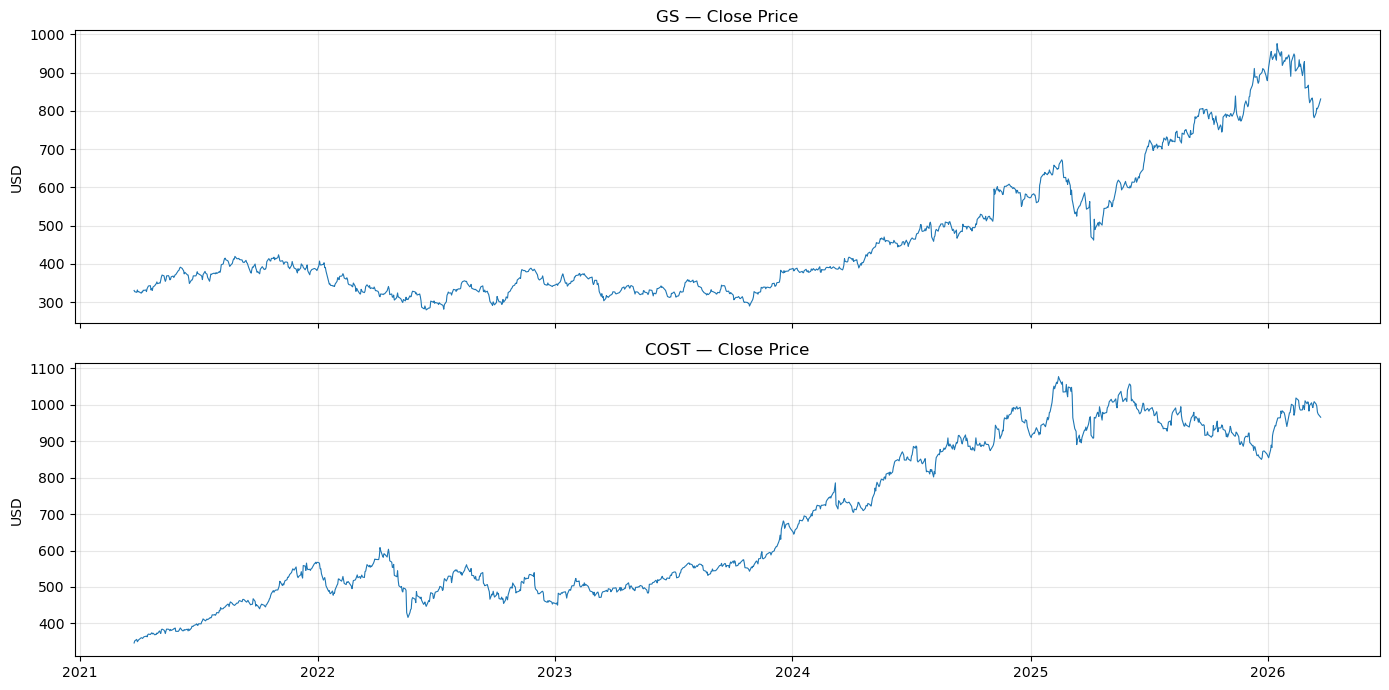

In [174]:
# ── Price time series ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, t in zip(axes, TICKERS):
    px = prices_raw[prices_raw['ticker'] == t]
    ax.plot(px['date'], px['close'], linewidth=0.8)
    ax.set_title(f'{t} — Close Price')
    ax.set_ylabel('USD')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

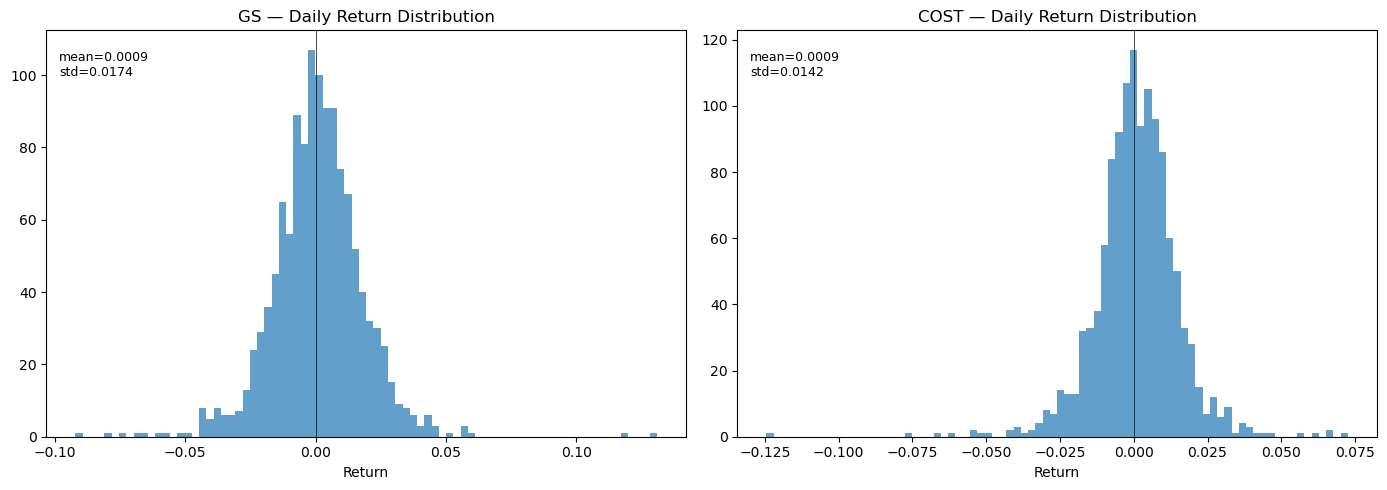

In [175]:
# ── Daily returns distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, t in zip(axes, TICKERS):
    px = prices_raw[prices_raw['ticker'] == t].copy()
    px['ret'] = px['close'].pct_change()
    ax.hist(px['ret'].dropna(), bins=80, edgecolor='none', alpha=0.7)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(f'{t} — Daily Return Distribution')
    ax.set_xlabel('Return')
    mean_r = px['ret'].mean()
    std_r  = px['ret'].std()
    ax.annotate(f'mean={mean_r:.4f}\nstd={std_r:.4f}', xy=(0.02, 0.95),
                xycoords='axes fraction', va='top', fontsize=9)

plt.tight_layout()
plt.show()

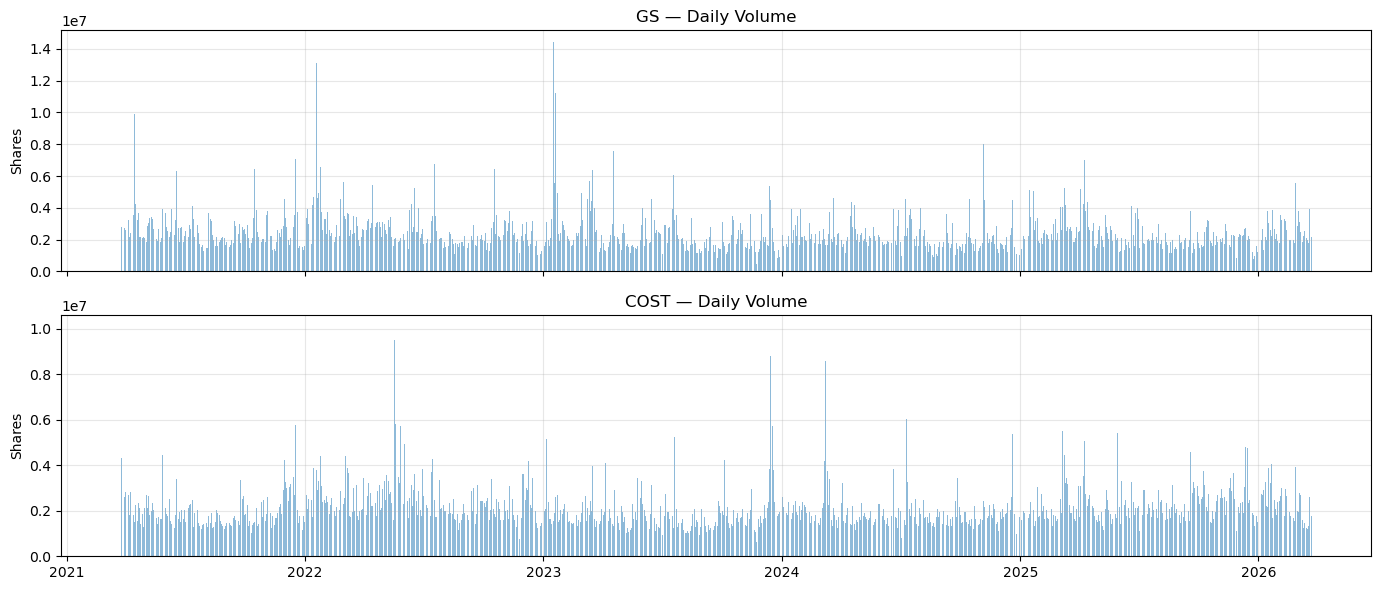

In [176]:
# ── Volume time series ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, t in zip(axes, TICKERS):
    px = prices_raw[prices_raw['ticker'] == t]
    ax.bar(px['date'], px['volume'], width=1, alpha=0.5)
    ax.set_title(f'{t} — Daily Volume')
    ax.set_ylabel('Shares')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

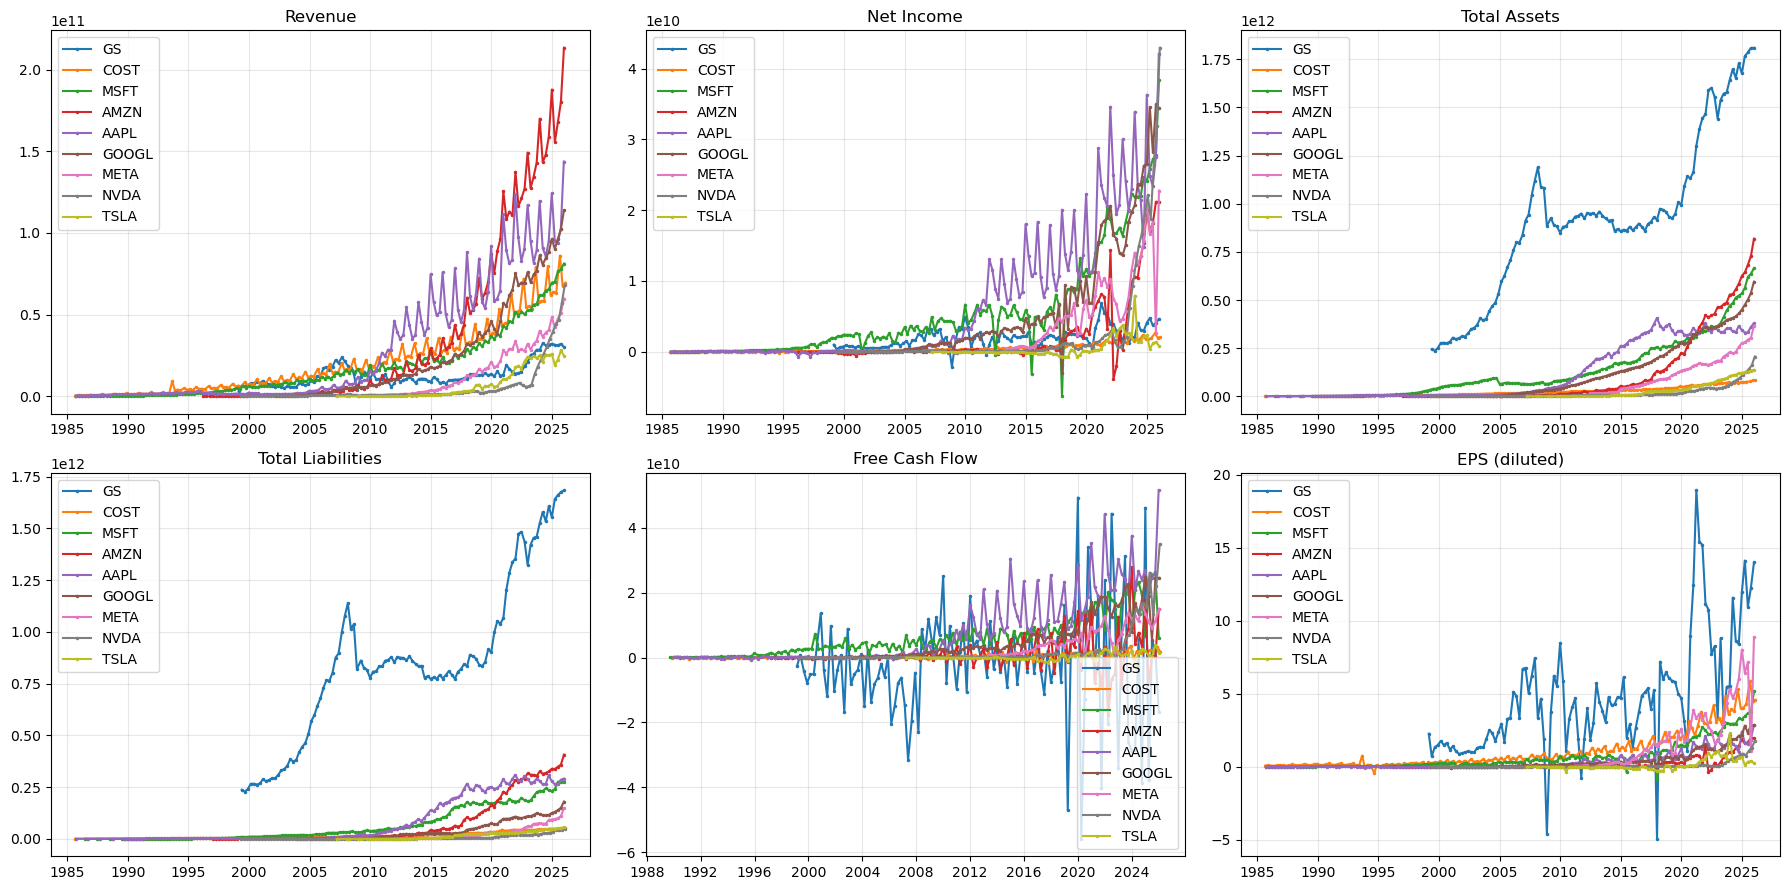

In [177]:
# ── Key fundamentals over time ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

metrics = [
    ('revenue', 'Revenue'),
    ('net_income', 'Net Income'),
    ('total_assets', 'Total Assets'),
    ('total_liabilities', 'Total Liabilities'),
    ('free_cash_flow', 'Free Cash Flow'),
    ('eps_diluted', 'EPS (diluted)'),
]

for ax, (col, label) in zip(axes.flat, metrics):
    for t in TICKERS:
        # pick the right statement
        for src_name, src in [('inc', inc_raw), ('bs', bs_raw), ('cf', cf_raw)]:
            if col in src.columns:
                df = src[src['symbol'] == t].copy()
                df['date'] = pd.to_datetime(df['date'])
                df = df.sort_values('date')
                ax.plot(df['date'], df[col], marker='.', markersize=3, label=t)
                break
    ax.set_title(label)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

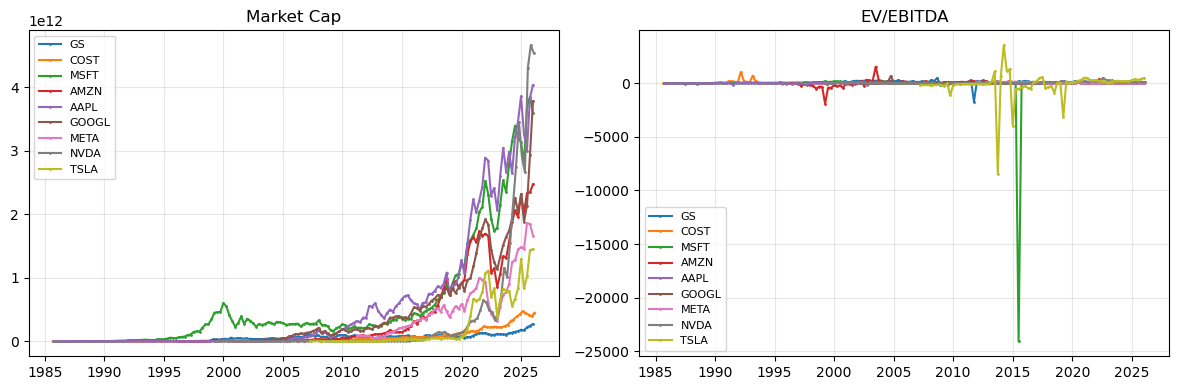

In [178]:
# ── Key metrics over time ─────────────────────────────────
km_metrics = [
    ('market_cap',              'Market Cap'),
    ('pe_ratio',                'P/E Ratio'),
    ('pb_ratio',                'P/B Ratio'),
    ('ev_to_ebitda',            'EV/EBITDA'),
    ('roe',                     'ROE'),
    ('roic',                    'ROIC'),
    ('dividend_yield',          'Dividend Yield'),
    ('debt_to_equity',          'Debt/Equity'),
    ('free_cash_flow_per_share','FCF per Share'),
    ('revenue_per_share',       'Revenue per Share'),
    ('net_income_per_share',    'Net Income per Share'),
    ('book_value_per_share',    'Book Value per Share'),
]

# filter to columns that actually exist
km_available = [(col, label) for col, label in km_metrics if col in km_raw.columns]
n = len(km_available)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes_flat = axes.flat

for i, (col, label) in enumerate(km_available):
    for t in TICKERS:
        sub = km_raw[km_raw['symbol'] == t].copy()
        sub['date'] = pd.to_datetime(sub['date'])
        sub = sub.sort_values('date')
        axes_flat[i].plot(sub['date'], sub[col], marker='.', markersize=2, label=t)
    axes_flat[i].set_title(label)
    axes_flat[i].legend(fontsize=8)
    axes_flat[i].grid(alpha=0.3)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

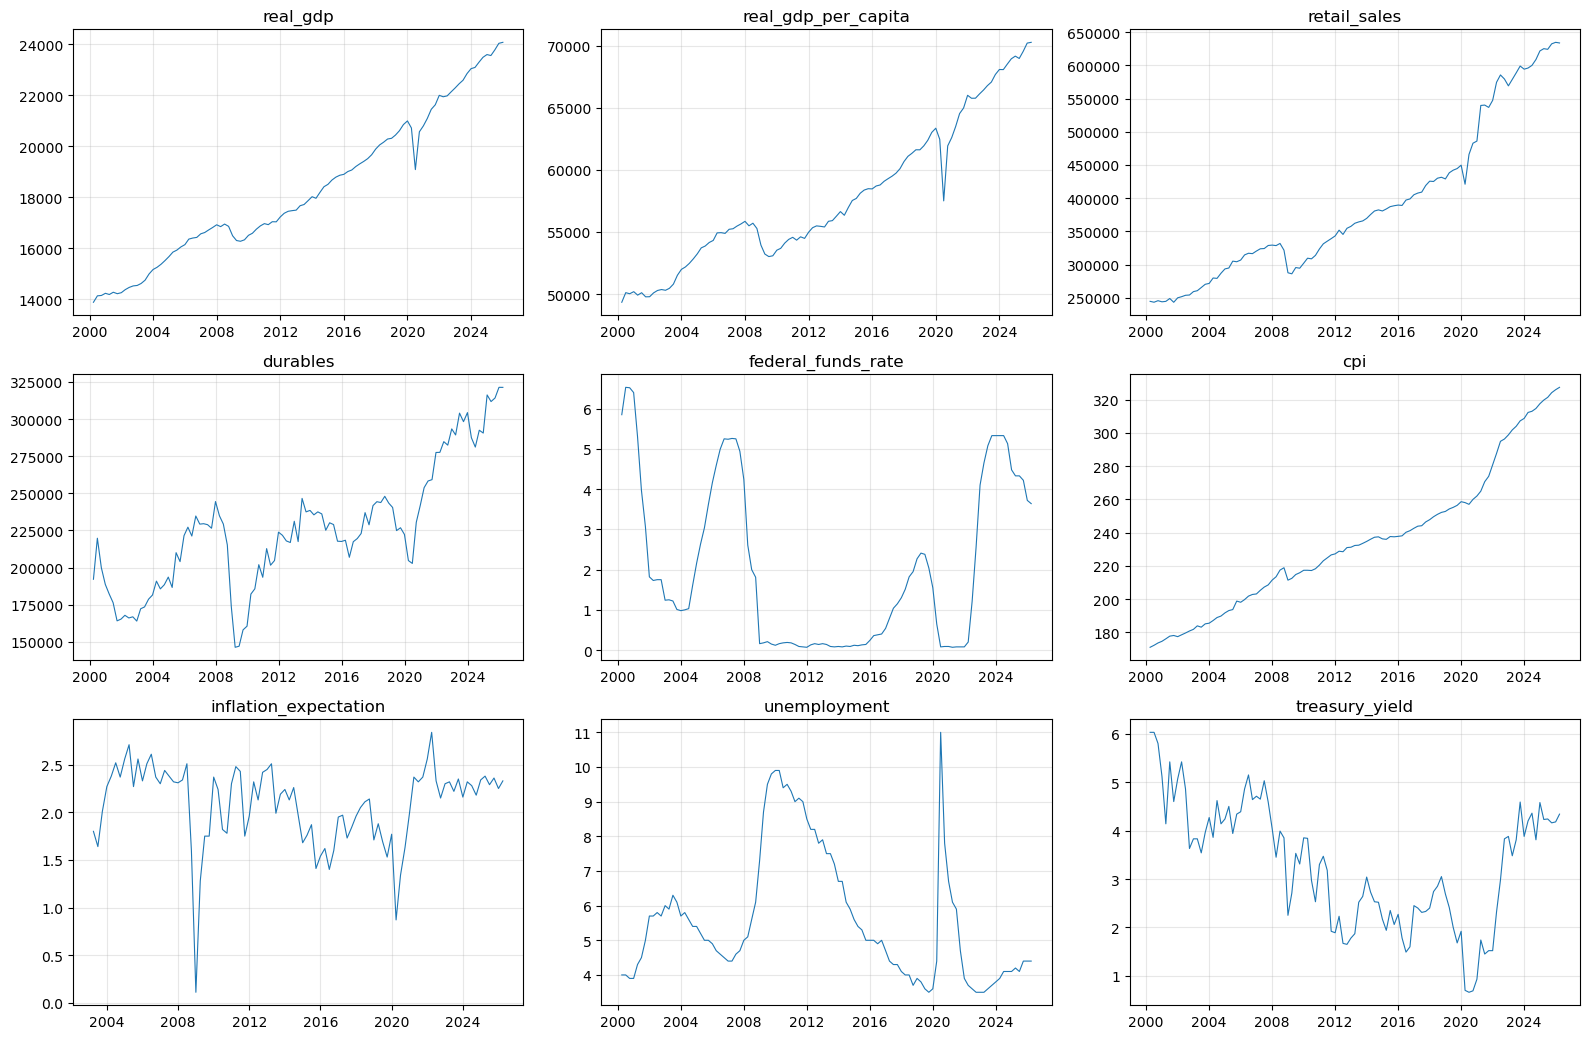

In [179]:
# ── Macro indicators over time ────────────────────────────
macro_plot_cols = [c for c in macro_df.columns if c != 'date']
n = len(macro_plot_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows))
axes = axes.flat

for i, col in enumerate(macro_plot_cols):
    tmp = macro_df[['date', col]].dropna()
    axes[i].plot(tmp['date'], tmp[col], linewidth=0.8)
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes.base.flat)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [180]:
# ── Company profiles ─────────────────────────────────────
profiles = pd.concat(
    [fmp_get('profile', symbol=t) for t in TICKERS], ignore_index=True
)
profiles = snakeify(profiles)
print(f'Profiles: {profiles.shape}')
profiles[['symbol', 'company_name', 'sector', 'industry', 'country', 'mkt_cap', 'exchange']].head()

Profiles: (9, 36)


KeyError: "['mkt_cap'] not in index"

## 6. Column Mapping — FMP vs SABER Skeleton

In [ ]:
# ── Show which SABER skeleton features exist in FMP data ──
from saber_feature_skeleton import (
    BALANCE_SHEET_FEATURES, CASHFLOW_FEATURES,
    INCOME_STATEMENT_FEATURES, FUNDAMENTAL_RATIO_FEATURES,
    MACRO_FEATURES,
)

def coverage_report(saber_cols, fmp_cols, name):
    fmp_set = set(fmp_cols)
    matched = [c for c in saber_cols if c in fmp_set]
    missing = [c for c in saber_cols if c not in fmp_set]
    pct = 100 * len(matched) / len(saber_cols) if saber_cols else 0
    print(f'\n{name}: {len(matched)}/{len(saber_cols)} matched ({pct:.0f}%)')
    if missing:
        print(f'  Missing: {missing[:15]}')
        if len(missing) > 15:
            print(f'  ... +{len(missing)-15} more')
    # also show FMP columns NOT in skeleton
    extra = sorted(set(fmp_cols) - set(saber_cols) - {'symbol', 'date', 'period',
        'reported_currency', 'cik', 'filling_date', 'accepted_date',
        'calendar_year', 'link', 'final_link'})
    if extra:
        print(f'  Extra FMP cols not in skeleton: {extra[:10]}')

coverage_report(BALANCE_SHEET_FEATURES, bs_raw.columns, 'Balance Sheet')
coverage_report(CASHFLOW_FEATURES, cf_raw.columns, 'Cash Flow')
coverage_report(INCOME_STATEMENT_FEATURES, inc_raw.columns, 'Income Statement')
coverage_report(MACRO_FEATURES, macro_df.columns if macro_df is not None else [], 'Macro')


Balance Sheet: 24/60 matched (40%)
  Missing: ['net_tangible_assets', 'earning_assets', 'cash', 'cash_and_equivalents', 'non_current_assets_total', 'non_current_assets_other', 'property_plant_equipment', 'property_plant_equipment_gross', 'short_long_term_debt', 'accounts_payable', 'non_current_liabilities_total', 'non_current_liabilities_other', 'long_term_debt_total', 'negative_goodwill', 'deferred_long_term_liabilities']
  ... +21 more
  Extra FMP cols not in skeleton: ['account_payables', 'accounts_receivables', 'accrued_expenses', 'accumulated_other_comprehensive_income_loss', 'capital_lease_obligations_current', 'capital_lease_obligations_non_current', 'cash_and_cash_equivalents', 'deferred_revenue', 'deferred_revenue_non_current', 'deferred_tax_liabilities_non_current']

Cash Flow: 5/29 matched (17%)
  Missing: ['begin_period_cash_flow', 'end_period_cash_flow', 'change_in_cash', 'cash_and_cash_equivalents_changes', 'change_to_operating_activities', 'change_to_net_income', 'total

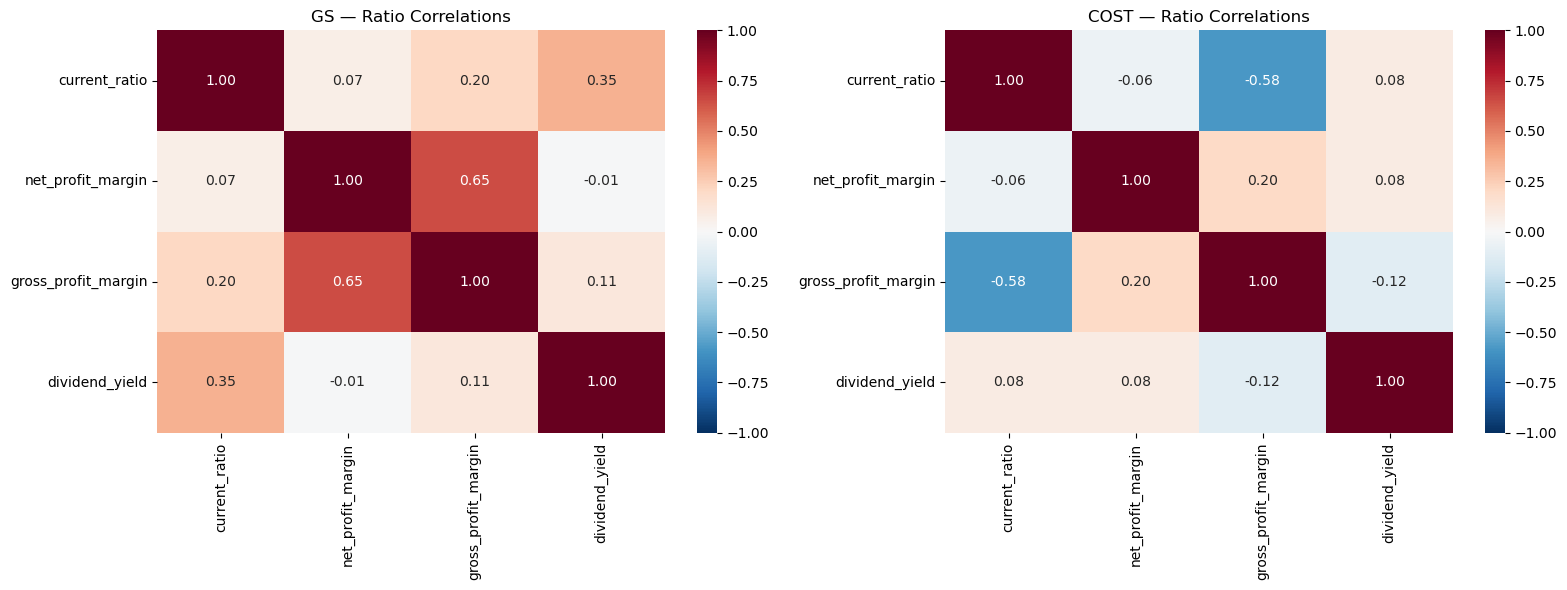

In [ ]:
# ── Correlation matrix for key ratios ─────────────────────
ratio_cols = [c for c in ['pe_ratio_t_t_m', 'pb_ratio', 'debt_equity_ratio',
    'current_ratio', 'return_on_equity', 'return_on_assets',
    'net_profit_margin', 'gross_profit_margin', 'dividend_yield',
    'price_to_free_cash_flows_ratio'] if c in rat_raw.columns]

if ratio_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, t in zip(axes, TICKERS):
        subset = rat_raw[rat_raw['symbol'] == t][ratio_cols].dropna(axis=1, how='all')
        if not subset.empty:
            corr = subset.corr()
            sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                        center=0, ax=ax, vmin=-1, vmax=1)
        ax.set_title(f'{t} — Ratio Correlations')
    plt.tight_layout()
    plt.show()

In [181]:
# ── Summary: data inventory ───────────────────────────────
inventory = pd.DataFrame([
    {'Dataset': 'Balance Sheet', 'Rows': len(bs_raw), 'Cols': bs_raw.shape[1],
     'NA%': f"{100*bs_raw.isna().mean().mean():.1f}%"},
    {'Dataset': 'Income Statement', 'Rows': len(inc_raw), 'Cols': inc_raw.shape[1],
     'NA%': f"{100*inc_raw.isna().mean().mean():.1f}%"},
    {'Dataset': 'Cash Flow', 'Rows': len(cf_raw), 'Cols': cf_raw.shape[1],
     'NA%': f"{100*cf_raw.isna().mean().mean():.1f}%"},
    {'Dataset': 'Key Metrics', 'Rows': len(km_raw), 'Cols': km_raw.shape[1],
     'NA%': f"{100*km_raw.isna().mean().mean():.1f}%"},
    {'Dataset': 'Ratios', 'Rows': len(rat_raw), 'Cols': rat_raw.shape[1],
     'NA%': f"{100*rat_raw.isna().mean().mean():.1f}%"},
    {'Dataset': 'Daily Prices', 'Rows': len(prices_raw), 'Cols': prices_raw.shape[1],
     'NA%': f"{100*prices_raw.isna().mean().mean():.1f}%"},
    {'Dataset': 'Macro', 'Rows': len(macro_df), 'Cols': macro_df.shape[1],
     'NA%': f"{100*macro_df.isna().mean().mean():.1f}%"},
])
display(inventory)

,Dataset,Rows,Cols,NA%
0,Balance Sheet,1000,61,0.0%
1,Income Statement,1051,39,0.0%
2,Cash Flow,993,47,0.0%
3,Key Metrics,1051,47,0.2%
4,Ratios,1051,64,0.0%
5,Daily Prices,11286,11,0.0%
6,Macro,105,10,1.3%
